In [1]:
import numpy as np
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
from numpy import pi, sqrt, exp, linspace, zeros, euler_gamma, log, einsum
import matplotlib.pyplot as plt

### The function below gives one contribution to a Green's function sum, $4\pi k^2 a^3\sum_{n, m}\mathbf{G}_{xx}(\mathbf{r}_{n, m}, \mathbf{0})$ for the case of a square lattice (where $n$ indexes the position along $x$ and $m$ indexes the position along $y$. The quantity returned is unitless and depends only on the ratio $\lambda/a$ (and of course the integers $n$ and $m$). We note that the component of the Dyadic function considered here corresponds to the electric field (evaluated at an arbitrary lattice site) that is  radiated by dipoles (from all other lattice sites), with such dipoles polarized along one of the lattice directions. 

In [11]:
# We define lambda  in units of a 
def one_term(n, m, lambda_):
    cos_sqrd = n**2/(n**2+m**2)
    sin_sqrd = 1-cos_sqrd
    kr = (2*pi/lambda_)*sqrt(n**2+m**2)
    denom = (n**2+m**2)**(3/2)
    num = (kr**2)*sin_sqrd + (3*cos_sqrd - 1) * (1-1j*kr)
    return (num/denom)*exp(1j*kr)

In [78]:
M = 20
lambda_v = linspace(1.01, 1.06, M)
dipole_sums = zeros(M)
N = 8000
for (sum_idx, lambda_) in enumerate(lambda_v):
    print("sum_idx: ", sum_idx)
    dipole_sum = 0 
    for n in range(0, N+1):
        for m in range(0, N+1):
            if n == 0 and m == 0:
                continue
            if n==0 or m == 0: 
                dipole_sum += 2*one_term(n, m, lambda_) # multiply by 4 or 2 to take in to account n->-n, m->-m
            else: 
                dipole_sum += 4*one_term(n, m, lambda_) # multiply by 4 or 2 to take in to account n->-n, m->-m
    dipole_sums[sum_idx] = dipole_sum.real 

sum_idx:  0
sum_idx:  1
sum_idx:  2
sum_idx:  3
sum_idx:  4
sum_idx:  5
sum_idx:  6
sum_idx:  7
sum_idx:  8
sum_idx:  9
sum_idx:  10
sum_idx:  11
sum_idx:  12
sum_idx:  13
sum_idx:  14
sum_idx:  15
sum_idx:  16
sum_idx:  17
sum_idx:  18
sum_idx:  19


### The plot below should resemble Figure 6 (a) in the paper [Colloquium: Light scattering by particle and hole arrays](https://journals.aps.org/rmp/pdf/10.1103/RevModPhys.79.1267)

In [79]:
def dipole_sum_asymptotic(lambda_):
    return 4*pi**2*sqrt(2)*(1/sqrt(lambda_-1))-118

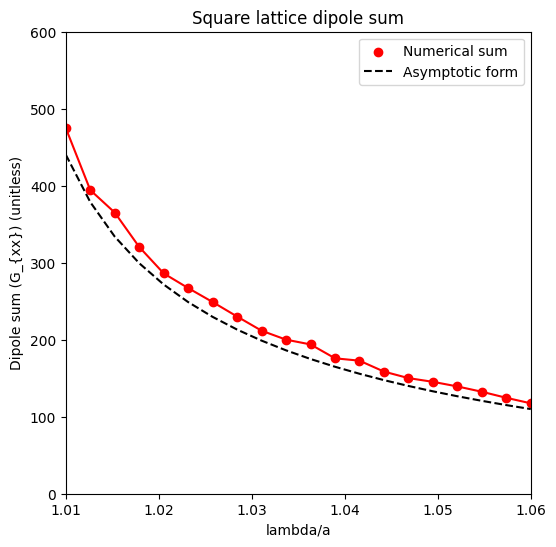

In [213]:
fig, ax = plt.subplots(figsize=(6, 6))
lambda_v = linspace(1.01, 1.06, M)
ax.scatter(lambda_v, dipole_sums, color="red", label="Numerical sum")
ax.plot(lambda_v, dipole_sums, color="red")

ax.plot(lambda_v, dipole_sum_asymptotic(lambda_v), linestyle="dashed", color="black", label="Asymptotic form")
ax.set_xlabel("lambda/a")
ax.set_ylim(0, 600)
ax.set_xlim(1.01, 1.06);
ax.set_ylabel("Dipole sum (G_{xx}) (unitless)");
ax.set_title("Square lattice dipole sum");
ax.legend();

### We now move on to the cylindrical case, with electric field along the cylinder axis. 

In [17]:
# We define lambda in units of a 
def one_term_cylinder(n, lambda_):
    kr = (2*pi/lambda_)*n
    coeff = 1j*(pi/lambda_)**2
    return coeff * hankel1(0, kr)

### To make the convergence faster, we may also perform the lattice sum in the Fourier domain (see e.g. **Equation 7** of [Extraordinary optical reflection fromsub-wavelength cylinder arrays](https://opg.optica.org/directpdfaccess/87a6fce8-e489-4bee-bbbfeae2114ce881_89577/oe-14-9-3730.pdf?da=1&id=89577&seq=0&mobile=no) specialized to normal incidence). 

In [22]:
# lambda is again defined in units of the lattice constant, a.
# One Fourier component of the Green's function sum in the Fourier domain (with reciprocal lattice vectors 2pi*m/a)
def one_term_cylinder_reciprocal(n, lambda_):
    coeff = (2*pi/lambda_)**2
    fourier_component = (1/(2*pi))*(1/sqrt(n**2-1/lambda_**2) - 1/n)
    return coeff * fourier_component 
# Constant that is left over (one term of which corresponds to the zero diffraction term--m=0)
def cylinder_reciprocal_constant(lambda_):
    coeff = (2*pi/lambda_)**2
    constant_1 = (1j/2) * (lambda_/(2*pi) - 1/4)
    constant_2 = (1/(2*pi)) * (euler_gamma - log(2*lambda_))
    return coeff * (constant_1 + constant_2)

In [4]:
M = 20
lambda_v = linspace(1.00001, 1.0001, M)
dipole_sums_cylinder = zeros(M)
N = 40000000
for (sum_idx, lambda_) in enumerate(lambda_v):
    print("sum_idx: ", sum_idx)
    dipole_sum = 0 
    for n in range(1, N+1):
        dipole_sum += 2*one_term_cylinder(n, lambda_) # multiply by 2 to take in to account n->-n
    dipole_sums_cylinder[sum_idx] = dipole_sum.real 

sum_idx:  0
sum_idx:  1
sum_idx:  2
sum_idx:  3
sum_idx:  4
sum_idx:  5
sum_idx:  6
sum_idx:  7
sum_idx:  8
sum_idx:  9
sum_idx:  10
sum_idx:  11
sum_idx:  12
sum_idx:  13
sum_idx:  14
sum_idx:  15
sum_idx:  16
sum_idx:  17
sum_idx:  18
sum_idx:  19


In [5]:
def dipole_sum_asymptotic_cylinder(lambda_):
    return 2*(pi)*1/sqrt(1-1/lambda_**2)

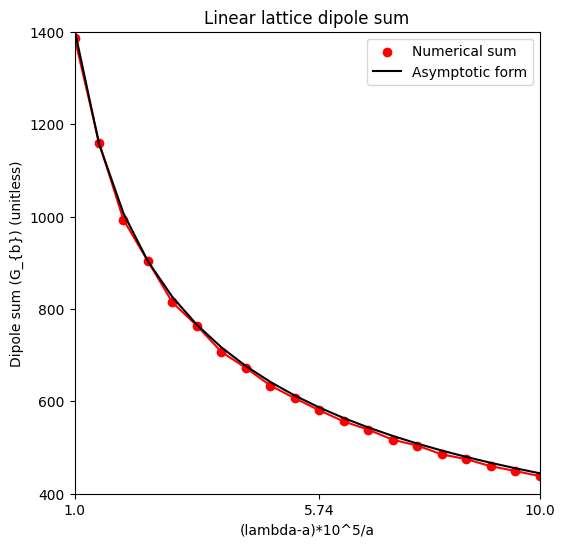

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
lambda_v = linspace(1.00001, 1.0001, M)
ax.scatter(lambda_v, dipole_sums_cylinder, color="red", label="Numerical sum")
ax.plot(lambda_v, dipole_sums_cylinder, color="red")
ax.plot(lambda_v, dipole_sum_asymptotic_cylinder(lambda_v), color="black", label="Asymptotic form")
ax.set_ylabel("Dipole sum (G_{b}) (unitless)");
ax.set_xlabel("(lambda-a)*10^5/a")
ax.set_xticks(lambda_v[[0, 10, 19]], ((lambda_v[[0, 10, 19]]-1)*100000).round(2))
ax.set_title("Linear lattice dipole sum");
ax.legend();
ax.set_xlim(lambda_v.min(), lambda_v.max());
ax.set_ylim(400, 1400);

In [23]:
M = 20
lambda_v = linspace(1.00001, 1.0001, M)
dipole_sums_cylinder_reciprocal = zeros(M)
N = 20
for (sum_idx, lambda_) in enumerate(lambda_v):
    dipole_sum = 0 
    for n in range(1, N+1):
        dipole_sum += one_term_cylinder_reciprocal(n, lambda_) # multiply by 2 to take in to account n->-n
    dipole_sum += cylinder_reciprocal_constant(lambda_) 
    dipole_sums_cylinder_reciprocal[sum_idx] = dipole_sum.real 

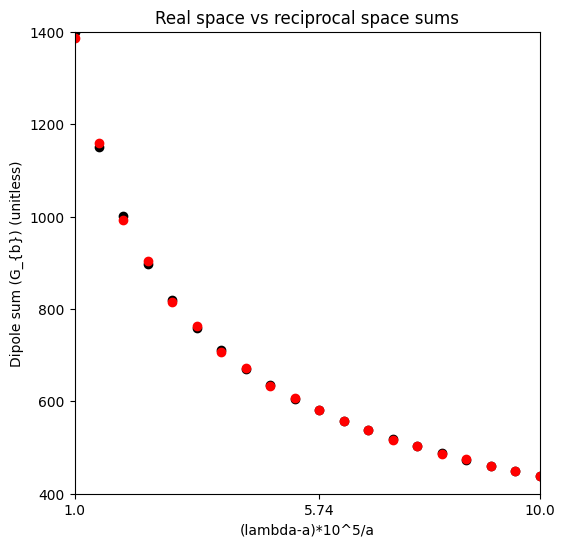

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(lambda_v, dipole_sums_cylinder_reciprocal, color="black")
ax.scatter(lambda_v, dipole_sums_cylinder, color="red", )
ax.set_title("Real space vs reciprocal space sums")
ax.set_ylabel("Dipole sum (G_{b}) (unitless)");
ax.set_xlabel("(lambda-a)*10^5/a")
ax.set_ylim(400, 1400);
ax.set_xticks(lambda_v[[0, 10, 19]], ((lambda_v[[0, 10, 19]]-1)*100000).round(2));
ax.set_xlim(lambda_v.min(), lambda_v.max());

### We now look at the component of the Dyadic, $a^2\sum_{m\neq 0}\partial_y^2 G(0, m)=-\frac{i}{4}\sum_m \frac{2\pi a}{m\lambda}H_1^{(1)}(2\pi ma/\lambda)$

In [2]:
# We define lambda in units of a 
def one_term_cylinder_yy(n, lambda_):
    kr = (2*pi/lambda_)*n
    coeff = -(1j/4)*(2*pi/n)/lambda_
    return coeff * hankel1(1, kr)

def closed_form_cylinder_yy_imaginary(lambda_):
    k = (2*pi/lambda_)
    return -k/2+k**2/8

### Note that the imaginary part of the lattice Green's function sum may be calculated analytically (which is what the function closed_form_cylinder_yy_imaginary does above). If $\lambda < a\leftrightarrow 2\pi < ka$, the result is especially simple. The result is derived by separating the lattice sum into two terms: $\sum_{m \neq 0}\Im\partial_y^2G(0, m)=\sum_{m} \Im\partial_y^2 G(0, m)- \Im\partial_y^2G(0, 0)$. Note that each of these terms is individually finite and they may be evaluated independently. The self-energy term gives:  $\lim_{\mathbf{r}\rightarrow\mathbf{r}_0}\partial_y^2\Im \text{G}(\mathbf{r}, \mathbf{r}_0)=\frac{1}{4}\partial_y^2J_0(k|\mathbf{r}-\mathbf{r}_0|)=\frac{1}{4}\Bigg[\frac{kJ_0'(kr)}{r}(1-(y/r)^2)+k^2(y/r)^2J_0''(kr)\Bigg]\\\approx -\frac{1}{8}k^2$. Furthermore, for the sum over all lattice sites, we have that $\sum_{m} \Im\partial_y^2 G(0, m) = \Im \partial_y^2 \frac{i}{2 (a\omega/c)}e^{iy\omega/c}\rightarrow-\frac{k}{2a}$. Therefore, we have that $a^2\sum_{m \neq 0}\Im\partial_y^2G(0, m)=-(ka)/2+(ka)^2/8$

In [3]:
M = 100
lambda_v = linspace(1.1, 3, M)
N_v = [100, 1000, 10000, 100000]
dipole_sums_cylinder_v = []
for (N_idx, N) in enumerate(N_v):
    print("N_idx: ", N_idx)
    dipole_sums_cylinder = zeros(M, dtype=complex)
    for (sum_idx, lambda_) in enumerate(lambda_v):
        dipole_sum = 0 
        for n in range(1, N+1):
            dipole_sum += 2*one_term_cylinder_yy(n, lambda_) # multiply by 2 to take in to account n->-n
        dipole_sums_cylinder[sum_idx] = dipole_sum
    dipole_sums_cylinder_v.append(dipole_sums_cylinder)

N_idx:  0
N_idx:  1
N_idx:  2
N_idx:  3


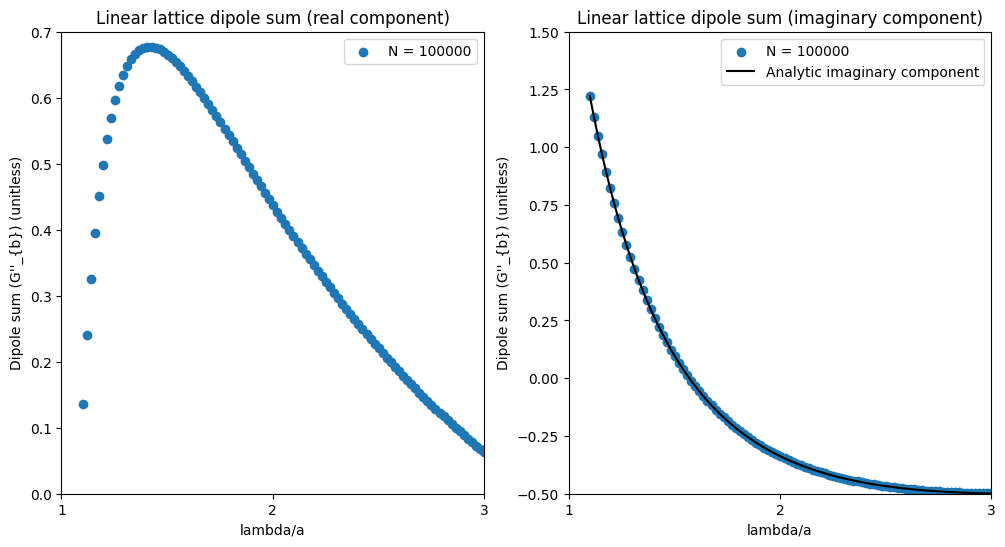

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for (N, dipole_sums_cylinder) in zip(N_v, dipole_sums_cylinder_v):
    if N != 100000:
        continue
    ax1.scatter(lambda_v, dipole_sums_cylinder.real, label=f"N = {N}")    
    ax2.scatter(lambda_v, dipole_sums_cylinder.imag, label=f"N = {N}")
ax2.plot(lambda_v, closed_form_cylinder_yy_imaginary(lambda_v), linestyle="solid", color="black", label="Analytic imaginary component")
ax1.set_ylabel("Dipole sum (G''_{b}) (unitless)");
ax2.set_ylabel("Dipole sum (G''_{b}) (unitless)");

ax1.set_xlabel("lambda/a")
ax2.set_xlabel("lambda/a")

ax1.set_title("Linear lattice dipole sum (real component)");
ax2.set_title("Linear lattice dipole sum (imaginary component)");

ax1.legend();
ax1.set_xlim(lambda_v.min(), lambda_v.max());

ax2.legend();
ax2.set_xlim(lambda_v.min(), lambda_v.max());

ax1.set_xlim(1, 3)
ax2.set_xlim(1, 3)

ax1.set_ylim(0, 0.7)
ax2.set_ylim(-0.5, 1.5);

ax1.set_xticks([1, 2, 3])
ax2.set_xticks([1, 2, 3]);
plt.savefig("./paper/lattice_sum.pdf")

### At this point, we wish to find the range of $kR$ ($R$ being the radius of the scatterer) and $k=2\pi/\lambda$ being the wavevector that we need to consider. If we have $\Gamma\equiv \lambda/a$, then the requirement that $R<a/2$ may be rewritten as $R<\lambda/2\Gamma\rightarrow kR<\pi/\Gamma$. In the below, we consider the range $1<\Gamma<3$, which means that $\pi/\Gamma>1$. Therefore, we may pick as a strict upper bound $kR<1$.

In [8]:
M = 200
s_v = zeros(M, dtype=complex)
lambda_v = linspace(1, 3, M)
N = 10000
dipole_sums_cylinder_v = []
for (sum_idx, lambda_) in enumerate(lambda_v):
    dipole_sum = 0 
    for n in range(1, N+1):
        dipole_sum += 2*one_term_cylinder_yy(n, lambda_) # multiply by 2 to take in to account n->-n
        # We define alpha_tilde as alpha (the polarizability) divided by a^2, where a is the lattice periodicity. 
    alpha_tilde_inv = -(dipole_sum + 1j * 2*pi/lambda_)
    s_v[sum_idx] = 1 + 1j*(2*pi/lambda_)**2/alpha_tilde_inv/4

In [9]:
# Check that we the Mie coefficients are all of absolute value less than unity (which they must be in the absence of gain). 
assert np.all(np.abs(s_v) < 1)

In [47]:
l = 1
idx = 100
s = s_v[idx]
max_kr = 1
x = linspace(max_kr/1000, max_kr, M) # Free space kR
n_m = 1
j_x = jv(l, x); 
j_nx = jv(l, n_m*x); 
y_x = yv(l, x); 

j_xprime = jvp(l, x);
j_nxprime = jvp(l, n_m*x);
y_xprime = yvp(l, x)

A_plus_iB = n_m*j_nx*((1+s)*j_xprime + 1j*(s-1)*y_xprime) - j_nxprime *((1+s)*j_x + 1j*(s-1)*y_x)
C_plus_iD = j_nxprime*((1+s)*j_xprime + 1j*(s-1)*y_xprime) 

A = A_plus_iB.real
B = A_plus_iB.imag
C = C_plus_iD.real
D = C_plus_iD.imag

mat = np.array([[-D, C], [-C, -D]])
vec = np.array([A, B])
prefac = -1/(D**2+C**2)
sigmas_cpa = prefac * einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas_cpa[0, :]
sigma_imaginary = sigmas_cpa[1, :]

In [48]:
tau = 6.4*1e-13 # scattering time in seconds
from utils import hbar, c, alpha

In [49]:
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;
hbar_omega = hbar*(sigma_imaginary/sigma_real)*(1/tau)

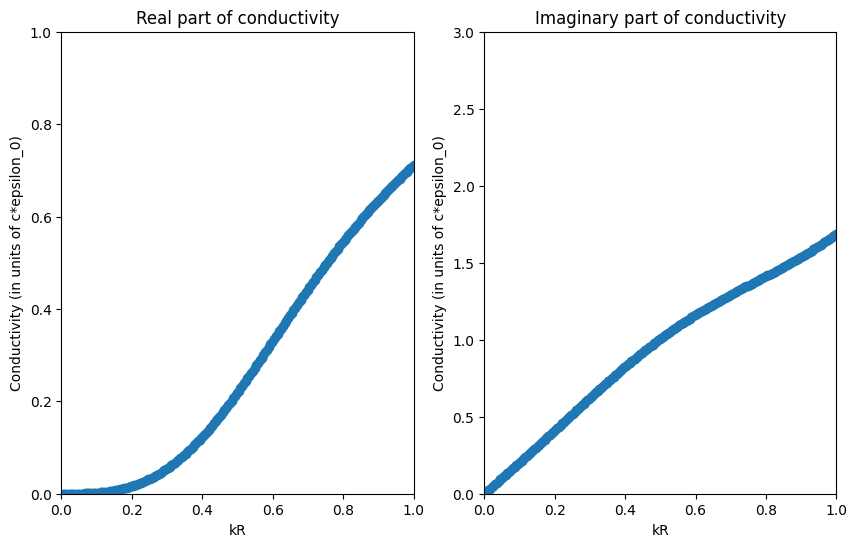

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.scatter(x, sigmas_cpa[0, :])
ax1.set_xlim(0, max_kr)
ax1.set_xlabel("kR")
ax1.set_title("Real part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_ylim(0, 1);

ax2.scatter(x, sigmas_cpa[1, :])
ax2.set_xlabel("kR")
ax2.set_xlim(0, max_kr)
ax2.set_title("Imaginary part of conductivity")
ax2.set_ylabel("Conductivity (in units of c*epsilon_0)");
ax2.set_ylim(0, 3);
#plt.savefig("./paper/lattice_cpa_conductivity.pdf")